In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mediapipe as mp
from mediapipe import solutions
import cv2
import os

In [12]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Flip horizontally (mirror effect)
    frame = cv2.flip(frame, 1)

    cv2.imshow("Mirrored Webcam", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [13]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7
)

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        print("Hand detected")

    # cv2.imshow("Hand Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

c:\Users\LENOVO\Documents\8th Semester\CV_Project\cv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Hand detected
Hand detected
Hand detected
Hand detected
Hand detected
Hand detected
Hand detected
Hand detected
Hand detected


KeyboardInterrupt: 

In [14]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # mirror view

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    result = hands.process(rgb)

    # If hand detected
    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:

            # Draw landmarks on hand
            mp_draw.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

            # Extract landmark coordinates
            h, w, _ = frame.shape
            landmarks = []

            # for id, lm in enumerate(hand_landmarks.landmark):
            #     x, y = int(lm.x * w), int(lm.y * h)
            #     landmarks.append((id, x, y))

            #     # Print each landmark (optional)
            #     print(f"ID: {id}, X: {x}, Y: {y}")

    cv2.imshow("Hand Landmarks", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [15]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

def extract_landmarks(frame):
    """Return 42 features (x,y for 21 landmarks)"""
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        hand = result.multi_hand_landmarks[0]

        h, w, _ = frame.shape
        features = []

        for lm in hand.landmark:
            features.append(lm.x)
            features.append(lm.y)

        return features, hand

    return None, None

In [19]:
import csv

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.7
)

DATASET_PATH = "asl_alphabet_train"
output_file = "asl_landmarks.csv"

with open(output_file, "w", newline="") as f:
    writer = csv.writer(f)

    # header (21 landmarks → x,y,z recommended)
    header = ["label"]
    for i in range(21):
        header += [f"x{i}", f"y{i}", f"z{i}"]
    writer.writerow(header)

    for label in os.listdir(DATASET_PATH):
        folder_path = os.path.join(DATASET_PATH, label)

        if not os.path.isdir(folder_path):
            continue

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = hands.process(rgb)

            if not result.multi_hand_landmarks:
                continue

            hand = result.multi_hand_landmarks[0]

            row = [label]

            for lm in hand.landmark:
                row.extend([lm.x, lm.y, lm.z])

            writer.writerow(row)

print("Dataset conversion complete!")

c:\Users\LENOVO\Documents\8th Semester\CV_Project\cv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Dataset conversion complete!


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# -----------------------------
# Load Dataset
# -----------------------------
data = pd.read_csv("asl_landmarks.csv")

# Features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# -----------------------------
# Encode Labels
# -----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes Found:")
print(le.classes_)

# Save labels
np.save("labels.npy", le.classes_)

# -----------------------------
# Normalize Features
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Save scaler for realtime inference
import joblib
joblib.dump(scaler, "scaler.pkl")

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -----------------------------
# Build MLP Model
# -----------------------------
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        256,
        activation='relu',
        input_shape=(X.shape[1],)
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        len(le.classes_),
        activation='softmax'
    )
])

# -----------------------------
# Compile
# -----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Callbacks
# -----------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
loss, acc = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {acc:.4f}")

# -----------------------------
# Save Model
# -----------------------------
model.save("asl_model.h5")

print("\nTraining Complete!")

Classes Found:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']
Epoch 1/50
1494/1494 [==============================] - 3s 2ms/step - loss: 0.4958 - accuracy: 0.8538 - val_loss: 0.1014 - val_accuracy: 0.9694
Epoch 2/50
1494/1494 [==============================] - 3s 2ms/step - loss: 0.1405 - accuracy: 0.9575 - val_loss: 0.0661 - val_accuracy: 0.9799
Epoch 3/50
1494/1494 [==============================] - 6s 4ms/step - loss: 0.1123 - accuracy: 0.9659 - val_loss: 0.0640 - val_accuracy: 0.9823
Epoch 4/50
1494/1494 [==============================] - 8s 5ms/step - loss: 0.0996 - accuracy: 0.9701 - val_loss: 0.0480 - val_accuracy: 0.9848
Epoch 5/50
1494/1494 [==============================] - 9s 6ms/step - loss: 0.0906 - accuracy: 0.9723 - val_loss: 0.0480 - val_accuracy: 0.9849
Epoch 6/50
1494/1494 [==============================] - 9s 6ms/step - loss: 0.0820 - accuracy: 0.9753 - val_loss: 0.0375 - val_accuracy: 0.9897


c:\Users\LENOVO\Documents\8th Semester\CV_Project\cv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [23]:
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp

# Load model + labels
model = tf.keras.models.load_model("asl_model.h5")
labels = np.load("labels.npy", allow_pickle=True)

# MediaPipe setup
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7
)

mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)

def extract_landmarks(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        hand = result.multi_hand_landmarks[0]

        data = []
        for lm in hand.landmark:
            data.extend([lm.x, lm.y, lm.z])

        return np.array(data), hand

    return None, None


while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    data, hand = extract_landmarks(frame)

    if hand:
        mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)

        if data is not None and data.shape[0] == 63:
            pred = model.predict(data.reshape(1, -1), verbose=0)
            class_id = np.argmax(pred)
            letter = labels[class_id]

            cv2.putText(frame, f"Prediction: {letter}",
                        (50, 80),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        2, (0, 255, 0), 3)

    cv2.imshow("A-Z Sign Language Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

c:\Users\LENOVO\Documents\8th Semester\CV_Project\cv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


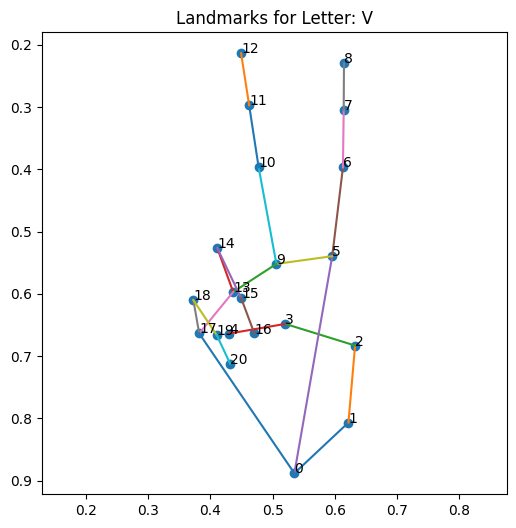

In [22]:
# Load dataset
df = pd.read_csv("asl_landmarks.csv")

# Choose letter to visualize
letter = "V"

# Get first sample of that letter
sample = df[df["label"] == letter].iloc[0]

# Extract x,y coordinates
x = []
y = []

for i in range(21):
    x.append(sample[f"x{i}"])
    y.append(sample[f"y{i}"])

# MediaPipe hand connections
connections = [
    (0,1),(1,2),(2,3),(3,4),        # thumb
    (0,5),(5,6),(6,7),(7,8),        # index
    (5,9),(9,10),(10,11),(11,12),   # middle
    (9,13),(13,14),(14,15),(15,16), # ring
    (13,17),(17,18),(18,19),(19,20),(0,17) # pinky
]

# Plot
plt.figure(figsize=(6,6))

# Draw connections
for start, end in connections:
    plt.plot(
        [x[start], x[end]],
        [y[start], y[end]]
    )

# Draw landmarks
plt.scatter(x, y)

# Landmark index labels
for i in range(21):
    plt.text(x[i], y[i], str(i))

plt.gca().invert_yaxis()  # image coordinates
plt.title(f"Landmarks for Letter: {letter}")
plt.axis("equal")
plt.show()

In [24]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1)

mp_draw = mp.solutions.drawing_utils

label = input("Enter word (e.g. hello): ")
file = "dynamic_dataset.csv"

sequence = []
SEQ_LEN = 30

cap = cv2.VideoCapture(0)

with open(file, "a", newline="") as f:
    writer = csv.writer(f)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)

        data = None

        if result.multi_hand_landmarks:
            hand = result.multi_hand_landmarks[0]
            mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)

            data = []
            for lm in hand.landmark:
                data.extend([lm.x, lm.y])

        if data:
            sequence.append(data)

        if len(sequence) > SEQ_LEN:
            sequence.pop(0)

        cv2.imshow("Dynamic Dataset Generator", frame)

        key = cv2.waitKey(1)

        # press S to save full sequence
        if key == ord('s') and len(sequence) == SEQ_LEN:
            writer.writerow([label] + np.array(sequence).flatten().tolist())
            print("Saved sequence")

        if key == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()